## Loading libraries and data

Here we load the necessary libraries. Note that while `pandas`, `numpy`, `sklearn`, `statsmodels`, `nltk` come with Anaconda distribution, you will probably have to install `stargazer` (for printing regression tables) and `plotly` (data visualization) manually.

Some codes and explanations here have been borrowed from *Natural Language Processing* specialization on Coursera:

* https://www.coursera.org/specializations/natural-language-processing

In [92]:
#@title
# This is to install some packages
# !pip install stargazer
# !pip install plotly
!pip install pyLDAvis
# You can comment it out later

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.3 MB/s eta 0:00:00


In [93]:
import pandas as pd      # Data frames
import numpy as np       # Fast matrix computations
import nltk              # Text processing

import statsmodels.api as sm
import plotly.express as px

# Notebook 4: unsupervised learning for text mining

Go through the notebook and do exercises. There will be topics for discussion in the end - we will discuss them in the next class.

By the end of this activity, you should

1. Know how to run principal component analysis, interpret and visualize principal components

2. Know how to run clustering analysis

3. Learn how to train Latent Dirichlet Allocation and how to interpret its output

The following command imports the CSV dataset using pandas:

In [94]:
# https://drive.google.com/file/d/1HbY4VKkjkLgUrwjzR-t7sThPjjX6amjZ/view?usp=sharing

import requests
from io import StringIO

# Set the file ID of the CSV file you want to load
file_id = "1HbY4VKkjkLgUrwjzR-t7sThPjjX6amjZ"

# Set the URL to download the file using the Drive API
url = f"https://drive.google.com/uc?id={file_id}&export=download"

# Make a GET request to download the file and decode the content
content = requests.get(url).content.decode("utf-8")

# Convert the string content to a pandas dataframe.

dataset = pd.read_csv(StringIO(content))


print("Data dimensions =", dataset.shape)
print("Here is the head of the data:")
dataset.head()

Data dimensions = (28276, 8)
Here is the head of the data:


,id,text,timestamp,source,symbols,company_names,url,verified
0,1.019697e+18,VIDEO: “I was in my office. I was minding my o...,Wed Jul 18 21:33:26 +0000 2018,GoldmanSachs,GS,The Goldman Sachs,https://twitter.com/i/web/status/1019696670777...,True
1,1.019709e+18,The price of lumber $LB_F is down 22% since hi...,Wed Jul 18 22:22:47 +0000 2018,StockTwits,M,Macy's,https://twitter.com/i/web/status/1019709091038...,True
2,1.019711e+18,Who says the American Dream is dead? https://t...,Wed Jul 18 22:32:01 +0000 2018,TheStreet,AIG,American,https://buff.ly/2L3kmc4,True
3,1.019717e+18,Barry Silbert is extremely optimistic on bitco...,Wed Jul 18 22:52:52 +0000 2018,MarketWatch,BTC,Bitcoin,https://twitter.com/i/web/status/1019716662587...,True
4,1.019718e+18,How satellites avoid attacks and space junk wh...,Wed Jul 18 23:00:01 +0000 2018,Forbes,ORCL,Oracle,http://on.forbes.com/6013DqDDU,True


And here is some simple description

In [95]:
dataset.describe()

,id
count,2.827600e+04
mean,1.018834e+18
std,9.914581e+14
min,9.671094e+17
25%,1.018362e+18
50%,1.019221e+18
75%,1.019585e+18
max,1.019743e+18


## Data exploration

First, let's do some sanity check - look at the values of "verified". They are supposed to be true or false. Below are counts of unique values in the "verified" column

In [96]:
dataset.verified.value_counts()

,count
verified,
False,27914
True,362


Now we will compute the number of characters in each tweet and store these numbers as a new variable called `nchar`.

In [97]:
dataset["nchar"] = dataset["text"].str.len()

Let's now look at the histogram of `nchar`:

In [98]:
fig = px.histogram(dataset, x = 'nchar', nbins = 30)
fig.update_layout(xaxis_title='Number of characters', yaxis_title = "Count", bargap = 0.1)
fig.show()

### Exercise 1

Remove tweets that are longer than 280 characters - they are probably some kind of a mistake. After doing it, report the shape of the dataset and plot the histogram of `nchar`.

In [99]:
dataset = dataset.loc[dataset["nchar"] <= 280 , :]
print("Dataset shape =", dataset.shape)

fig = px.histogram(dataset, x = 'nchar', nbins=30)
fig.update_layout(xaxis_title='Number of characters', yaxis_title = "Count", bargap = 0.1)
fig.show()

Dataset shape = (28270, 9)


# Data processing

Now we will clean and stem the data and produce the document-term matrix. First, we do the cleaning (in the same way as in Notebook 3):

In [100]:
nltk.download('stopwords')

import re                                  # library for regular expression operations
import string                              # for string operations

from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings
stopwords_english = stopwords.words('english')

def process_tweet(tweet):
    """Process tweet function.
    Input:
        tweet: a string containing a tweet
    Output:
        tweets_clean: a list of words containing the processed tweet
        Modified: the string with the processed tweet

    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')
    # remove stock market tickers like $GE
    tweet = re.sub(r'\$\w*', '', tweet)
    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            # tweets_clean.append(word)
            stem_word = stemmer.stem(word)  # stemming word
            tweets_clean.append(stem_word)

    return ' '.join(tweets_clean)

dataset["clean_text"] = dataset["text"].apply(process_tweet, 1)
print("Here is the head of our dataset")
dataset.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-100-f530f38e1257>:46: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



Here is the head of our dataset


,id,text,timestamp,source,symbols,company_names,url,verified,nchar,clean_text
0,1.019697e+18,VIDEO: “I was in my office. I was minding my o...,Wed Jul 18 21:33:26 +0000 2018,GoldmanSachs,GS,The Goldman Sachs,https://twitter.com/i/web/status/1019696670777...,True,140.0,video “ offic mind busi ... ” – david solomon ...
1,1.019709e+18,The price of lumber $LB_F is down 22% since hi...,Wed Jul 18 22:22:47 +0000 2018,StockTwits,M,Macy's,https://twitter.com/i/web/status/1019709091038...,True,136.0,price lumber 22 sinc hit ytd high macy' turnar...
2,1.019711e+18,Who says the American Dream is dead? https://t...,Wed Jul 18 22:32:01 +0000 2018,TheStreet,AIG,American,https://buff.ly/2L3kmc4,True,60.0,say american dream dead
3,1.019717e+18,Barry Silbert is extremely optimistic on bitco...,Wed Jul 18 22:52:52 +0000 2018,MarketWatch,BTC,Bitcoin,https://twitter.com/i/web/status/1019716662587...,True,140.0,barri silbert extrem optimist bitcoin predict ...
4,1.019718e+18,How satellites avoid attacks and space junk wh...,Wed Jul 18 23:00:01 +0000 2018,Forbes,ORCL,Oracle,http://on.forbes.com/6013DqDDU,True,130.0,satellit avoid attack space junk circl earth paid


In [101]:
print("dim(data) =", dataset.shape)

dim(data) = (28270, 10)


## DTM

Here we will create the document-term matrix

In [102]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(dataset["clean_text"])
DTM = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print("Sample of DTM:")
print(DTM.iloc[[10000, 15000, 20000] , [2000, 3500, 5000]])
print("dim(DTM) =", DTM.shape)

Sample of DTM:
       apunto  consortium  five
10000       0           0     0
15000       0           0     0
20000       0           0     0
dim(DTM) = (28270, 12328)


Note that the DTM is huge. It has too many features and a lot of them are probably not very useful. There should be some words that appear only once or twice in the whole corpus and we can't possibly rely on such words for prediction. Besides, training a machine-learning model with such a large number of featues may be too time-consuming.

In [103]:
term_freq = DTM.sum(axis = 0)
print("Here is a sample of term frequencies:")
print(term_freq[[1000, 1500, 2000]])

Here is a sample of term frequencies:
4152      1
aaf       3
apunto    2
dtype: int64


<ipython-input-103-9c97cb68e90c>:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [104]:
print("There are", np.sum(term_freq == 1), "terms that appear only once")
print("There are", np.sum(term_freq == 2), "terms that appear only twice")

There are 4954 terms that appear only once
There are 1773 terms that appear only twice


In [105]:
df_term_freq = pd.DataFrame(data = {'term': DTM.columns.values, 'freq': term_freq})
df_term_freq = df_term_freq.sort_values(["freq"], ascending = False)

fig = px.bar(df_term_freq.head(20), x='term', y='freq')
fig.show()

Let us only use words that appear more often than a certain threshold in the model. The choice of the threshold is probably somewhat arbitrary.

In [106]:
threshold_for_freq = 200
print("Frequent terms are terms that appear at least", threshold_for_freq, "times")
frequent_terms = DTM.columns.values[term_freq >= threshold_for_freq]
print("Found" , frequent_terms.shape[0], "frequent terms")
print("Some frequent terms are")
print(frequent_terms[95:115])

Frequent terms are terms that appear at least 200 times
Found 185 frequent terms
Some frequent terms are
['join' 'juli' 'last' 'like' 'list' 'llc' 'long' 'look' 'low' 'lower'
 'ltd' 'make' 'manag' 'market' 'matur' 'max' 'maxpain' 'mid' 'million'
 'morgan']


Now we will create a subset of the DTM by choosing only columns that contain frequent terms. This trimmed DTM will serve as the matrix of features.

In [107]:
DTM_trimmed = DTM[frequent_terms]
print("Sample of X:")
print(DTM_trimmed.iloc[[12, 19, 6568, 8128], [75, 97, 110]])
print("dim(X) =", DTM_trimmed.shape)

Sample of X:
      form  last  max
12       0     0    0
19       0     0    0
6568     0     0    0
8128     0     0    0
dim(X) = (28270, 185)


# PCA

## PCA as a matrix product

PCA transforms an old numeric dataset $X_{old}$ to a new numeric dataset $X_{new}$. Usually, $X_{new}$ has fewer variables than $X_{old}$.

To understand PCA, we will de-mean the data, i.e., replace every variable $X$ with $X-\bar{X}$ in the data. In practice, this is done automatically under the hood of PCA routines.

In [108]:
Xold = np.array(DTM_trimmed)
Xold = Xold - np.mean(Xold, axis = 0)
print("Sample of Xold:")
print(Xold[:5, :5])
print("Sanity check: we should get a vector of zeroes")
print(np.mean(Xold, axis = 0)[:5])

Sample of Xold:
[[-0.05454545 -0.03848603 -0.02016272 -0.01018748 -0.007393  ]
 [-0.05454545 -0.03848603 -0.02016272 -0.01018748 -0.007393  ]
 [-0.05454545 -0.03848603 -0.02016272 -0.01018748 -0.007393  ]
 [-0.05454545 -0.03848603 -0.02016272 -0.01018748 -0.007393  ]
 [-0.05454545 -0.03848603 -0.02016272 -0.01018748 -0.007393  ]]
Sanity check: we should get a vector of zeroes
[-3.70480628e-15 -3.05066323e-15  3.52971003e-16 -3.07062010e-16
 -6.62954552e-16]


Now we will do PCA. It works by finding an orthonormal transformation matrix $T$ and setting
$$
X_{new}=X_{old}T,
$$
where the new data has uncorrelated variables. If the number of principal components is smaller than the number of original variables, then principal components will explain a certain fraction of the total variance in the initial data.

Below we print dimensions of the matrices to make sure that matrix multiplication makes sense.

In [109]:
from sklearn.decomposition import PCA
num_pc = 12
print("We will do PCA with", num_pc, "principal components")
pca = PCA(n_components = num_pc)
pca.fit(Xold)
# print(pca.explained_variance_ratio_)
print("Fraction of variance explained by PCA:", np.round(np.sum(pca.explained_variance_ratio_), 3))

# Below we compute new variables using the built-in routine
Xnew = pca.fit_transform(DTM_trimmed)
# And now we create a data frame for new variables
pca_df = pd.DataFrame(data = Xnew, columns = ['PC' + str(x+1) for x in range(num_pc)])

T = pca.components_.T
print("dim(Xold) =", Xold.shape)
print("dim(T) =", T.shape)
print("dim(Xnew) =", pca_df.shape)

We will do PCA with 12 principal components
Fraction of variance explained by PCA: 0.34
dim(Xold) = (28270, 185)
dim(T) = (185, 12)
dim(Xnew) = (28270, 12)


Matrix dimensions are consistent with matrix multiplication.

The next thing we will check is that $T$ is an orthonormal matrix. It means that pairwise dot products of its columns should be 1 or 0, i.e., $T^tT=I$. Let's check that

In [110]:
print("We should get the identity matrix:")
np.round(np.dot(T.T, T)[:5, :5], 10)

We should get the identity matrix:


array([[ 1., -0., -0., -0.,  0.],
       [-0.,  1., -0.,  0.,  0.],
       [-0., -0.,  1., -0.,  0.],
       [-0.,  0., -0.,  1., -0.],
       [ 0.,  0.,  0., -0.,  1.]])

Now let's check that the new variables are uncorrelated.

In [111]:
print("We should get the identity matrix:")
np.round(np.corrcoef(Xnew, rowvar = False), 10)[:5, :5]

We should get the identity matrix:


array([[ 1., -0., -0., -0.,  0.],
       [-0.,  1.,  0.,  0.,  0.],
       [-0.,  0.,  1.,  0., -0.],
       [-0.,  0.,  0.,  1.,  0.],
       [ 0.,  0., -0.,  0.,  1.]])

Now let's check that the matrix of new variables obtained by multiplying the matrix of old variables by $T$ and the matrix of new variables extracted by the native Python method is really the same thing

In [112]:
print("Sample of X*T:")
print(np.dot(Xold, T)[:5, :5])

print("Sample of Xnew:")
print(Xnew[:5, :5])

Sample of X*T:
[[-0.06403409 -0.11603712 -0.16632066  0.02148908 -0.08726595]
 [ 0.19176012 -0.10591996  0.05113342 -0.40005493 -0.19198569]
 [-0.05784792 -0.13901845 -0.1714352   0.02736959 -0.09263252]
 [-0.06820586 -0.26134459 -0.12228751  0.02118718 -0.01016652]
 [-0.05942263 -0.17791423 -0.09128433 -0.07858574 -0.1885955 ]]
Sample of Xnew:
[[-0.06403409 -0.11603712 -0.16632066  0.02148908 -0.08726595]
 [ 0.19176012 -0.10591996  0.05113342 -0.40005493 -0.19198569]
 [-0.05784792 -0.13901845 -0.1714352   0.02736959 -0.09263252]
 [-0.06820586 -0.26134459 -0.12228751  0.02118718 -0.01016652]
 [-0.05942263 -0.17791423 -0.09128433 -0.07858574 -0.1885955 ]]


## Interpretation of PCA

Now let's interpret principal components. Each of them is a linear combination of the original features and we can look at which features contribute most to each of the principal components to give some meaning to PCA.

Below we create a data frame whose columns are principal components, rows are original features, and entries are cotribution of original features into principal components.

In [113]:
pca_interpretation_df = pd.DataFrame(data = T,
                                     columns = ['PC' + str(x+1) for x in range(num_pc)],
                                     index = list(DTM_trimmed.columns))
pca_interpretation_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
00,0.412627,0.095428,0.098885,-0.248578,-0.005730,-0.125035,-0.039845,-0.113172,0.171128,-0.029630,-0.132170,0.009157
07,0.328389,0.074086,0.002943,0.109776,0.026004,0.145206,-0.000162,-0.027212,-0.002454,0.047137,0.004915,-0.025345
10,0.002196,-0.025470,0.001160,0.018446,0.021054,0.007954,0.009663,0.001001,0.011255,-0.010162,-0.018222,-0.036906
100,0.013714,-0.016319,0.018070,-0.020433,-0.026223,0.023848,0.023954,0.046929,-0.068619,0.003322,-0.007145,-0.027948
11,0.004106,0.004596,-0.002656,0.017619,-0.002497,0.011779,0.000925,0.003135,0.008751,-0.002080,0.002196,0.003883
...,...,...,...,...,...,...,...,...,...,...,...,...
want,-0.002513,-0.010556,0.005885,0.004247,0.001707,-0.004392,0.002136,0.011275,-0.004231,-0.001442,0.039170,0.021974
watch,-0.002901,-0.010186,-0.019049,-0.005779,0.006190,0.002766,0.008325,0.017588,-0.003679,-0.009603,0.018333,0.000004
week,-0.013510,0.025329,0.002599,0.003441,-0.007738,-0.046803,-0.070041,0.114004,0.066501,0.061826,0.173186,-0.123260
year,0.004085,-0.003898,-0.018388,0.009490,-0.002206,0.007007,0.003128,0.005599,-0.000673,-0.006305,-0.007312,0.008065


Let's look at top five words that contribute to PC1:

In [114]:
pca_interpretation_df['PC1'][np.argsort(-np.abs(pca_interpretation_df['PC1']))][:5]

<ipython-input-114-84690041fd88>:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



,PC1
00,0.412627
option,0.405507
2018,0.369980
07,0.328389
maxpain,0.268839


### Exercise 2

Write a function whose input is a numeric column in a data frame and whose output the top five entries with the largest absolute value and apply this function to PC2 and PC3 to get their meaning.

In [115]:
def top_abs(x, n = 5):
    # sorts x in the order of decreasing absolute value
    # returns the first n entries of the result
    return x[np.argsort(-np.abs(x))][:n]

print("PC2 mostly consists of:")
print(top_abs(pca_interpretation_df['PC2']))

print("PC3 mostly consists of:")
print(top_abs(pca_interpretation_df['PC3']))

PC2 mostly consists of:
inc       0.657996
trade    -0.268038
regist   -0.221896
bonu     -0.208291
binanc   -0.191261
Name: PC2, dtype: float64
PC3 mostly consists of:
inc       0.453691
trade     0.322900
regist    0.293465
bonu      0.279679
binanc    0.245620
Name: PC3, dtype: float64


<ipython-input-115-73ea1490b2e7>:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-115-73ea1490b2e7>:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



## Visualization

PCA is a popular technique for dimension reduction. It is useful to visualize data as a scatterplot. Indeed, if originally the data has a lot of variables, we can't just plot them. But if we project our dataset onto a plane, then we can at least look at such a projection. Of course, a 2D projection inevitably loses information as compared to the original dataset. However, by construction, the two principal components span the plane projection onto which leads to the minimal loss of information among all projections onto planes.

In [116]:
fig = px.scatter(pca_df, x = 'PC1', y = 'PC2', opacity = 0.1)
# fig.update_layout(xaxis_title='PC1', yaxis_title = "PC2")
fig.show()

### Exercise 3

Produce the scatterplot of our tweets where each tweet is prepresented by a point on the axes PC1, PC2 and coloured according to the source of the tweet. Since there are just too many different sources, you can use a small number of colours for most frequent sources and use a label like "others" for the rest of them.

In [117]:
### We will assign colours to 10 most frequent sources and use the label "others" for the rest of them

top10_values = dataset["source"].value_counts()[:10].index
top10_values

col = dataset["source"]
col[~dataset["source"].isin(top10_values)] = "others"

fig = px.scatter(pca_df, x = 'PC1', y = 'PC2', opacity = 0.5, color = col)
# fig.update_layout(xaxis_title='PC1', yaxis_title = "PC2")
fig.show()


<ipython-input-117-4f7896bacaea>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Clustering

For $K$-means clustering, we need to specify $K$, the number of clusters.

In [118]:
from sklearn.cluster import KMeans

K = 5
print("We are doing K-means clustering with K =", K)
kmeans = KMeans(K, random_state = 8128)           # Random state is chosen for reproducibility
kmeans.fit(Xnew)
identified_clusters = kmeans.fit_predict(Xnew)
pca_df["cluster"] = identified_clusters
pca_df["cluster"] = pca_df["cluster"].apply(str)  # This is to convert numeric labels to strings for plotting
print("Cluster frequencies:")
pca_df["cluster"].value_counts()

We are doing K-means clustering with K = 5
Cluster frequencies:


,count
cluster,
3,20947
1,3452
0,1989
4,1267
2,615


And here the scatterplot with clusters:

In [119]:
fig = px.scatter(pca_df, x = 'PC1', y = 'PC2', opacity = 0.5, color = 'cluster')
fig.show()

### Exercise 4

Print a sample of tweets from all the clusters except for the most common one.

In [120]:
print("Sample of cluster 3:")
print(dataset["text"][np.array(pca_df["cluster"] == "3")].sample(5, random_state = 28))

print("Sample of cluster 0:")
print(dataset["text"][np.array(pca_df["cluster"] == "0")].sample(5, random_state = 28))

print("Sample of cluster 1:")
print(dataset["text"][np.array(pca_df["cluster"] == "1")].sample(5, random_state = 28))

print("Sample of cluster 4:")
print(dataset["text"][np.array(pca_df["cluster"] == "4")].sample(5, random_state = 28))

Sample of cluster 3:
2607     RT @chartseer: Long setups $IRDM $FTNT $ESRX $...
17278    Fast / Cheap orders on discounted Fortnite vBu...
13891    RT @PinkSheetSutter: Staggered entry: Settleme...
22879    $AGNCB $AGNCN $AI $ARR $CHMI $CIM $CYS $DX $IV...
7502     Reviewing ConocoPhillips $COP &amp; Hess $HES ...
Name: text, dtype: object
Sample of cluster 0:
17356    Align Technology Inc. $ALGN Expected to Announ...
8798     RT @eWhispers: upcoming #earnings releases wit...
4995     $SYMC Q1 2019 Symantec Earnings Conference Cal...
7861     Newfield Exploration $NFX Earns Equal Weight R...
19139    Corning $GLW Set to Announce Earnings on Wedne...
Name: text, dtype: object
Sample of cluster 1:
8626     National Oilwell Varco Inc $NOV Institutional ...
22287    Rockwell Collins INC $COL Shareholder Carlson ...
16847    Stefano Pessina Buys 1697438 Shares of Walgree...
5463     Beach Investment Counsel INC Has Boosted Energ...
10402    $1.48 EPS Expected for Dr Pepper Snapple Group...


# Latent Dirichlet Allocation

## Training the model

We will follow this tutorial (Fedor doesn't know if it is possible to do LDA from the document-term matrix that we have so far, but it's alright, we will learn a different method of cleaning text and constructing a DTM):

https://towardsdatascience.com/topic-modeling-and-latent-dirichlet-allocation-in-python-9bf156893c24

There is a Python library for visualizing LDA models, but Fedor couldn't figure out how to use it (you are welcome to try, however)

In [121]:
documents = dataset["text"]

from pprint import pprint
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from nltk.stem import WordNetLemmatizer, SnowballStemmer
import numpy as np
np.random.seed(2018)
import nltk
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [122]:
def lemmatize_stemming(text):
    stemmer = PorterStemmer()
    return stemmer.stem(WordNetLemmatizer().lemmatize(text, pos='v'))

def preprocess(text):
    result = []
    for token in gensim.utils.simple_preprocess(text):
        if token not in gensim.parsing.preprocessing.STOPWORDS and len(token) > 3:
            result.append(lemmatize_stemming(token))
    return result

some_doc_index = 8128
doc_sample = documents[some_doc_index]
print('original document: ')
words = []
for word in doc_sample.split(' '):
    words.append(word)
print(words)
print('\n\n tokenized and lemmatized document: ')
print(preprocess(doc_sample))

original document: 
['Will', 'Republic', 'Services', 'Inc.', '$RSG', 'Run', 'Out', 'of', 'Steam', 'Soon?', '-', 'https://t.co/3DRSmtv5kk']


 tokenized and lemmatized document: 
['republ', 'servic', 'steam', 'soon', 'http', 'drsmtv']


In [123]:
processed_docs = documents.map(preprocess)
processed_docs[:10]

,text
0,"[video, offic, mind, busi, david, solomon, tel..."
1,"[price, lumber, lb_f, hit, high, maci, turnaro..."
2,"[say, american, dream, dead, http, crgx]"
3,"[barri, silbert, extrem, optimist, bitcoin, pr..."
4,"[satellit, avoid, attack, space, junk, circl, ..."
5,"[realmoney, david, butler, favorit, fang, stoc..."
6,"[miss, convo, favorit, thinker, samharrisorg, ..."
7,"[intellig, document, nelson, mandela, public, ..."
8,"[senat, want, emerg, alert, netflix, spotifi, ..."
9,"[hedg, fund, manag, marc, larsi, say, bitcoin,..."


We will use a function from the library `gensim` to create a special dictionary with all the words that appear in our corpus. Note that we first use all existing words and then filter out words that appear in fewer than 15 documents and words that appear in more than 50% of documents.

In [124]:
dictionary = gensim.corpora.Dictionary(processed_docs)
print("Number of words before filtering =", len(dictionary))
dictionary.filter_extremes(no_below=15, no_above=0.5)
print("Number of words after filtering =", len(dictionary))
print("First few words are")
vocab = []
count = 0
for k, v in dictionary.iteritems():
    if count < 10:
        print(k, v)
    count += 1
    vocab.append(v)


Number of words before filtering = 34806
Number of words after filtering = 1936
First few words are
0 busi
1 david
2 intern
3 learn
4 mind
5 offic
6 tell
7 video
8 happen
9 high


Now we will create a document-term matrix and store it into the variable `bow_corpus` ("bow" stands for "bag of words"). This is what it looks like

In [125]:
bow_corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
print("How the matrix version of a document")
print(bow_corpus[some_doc_index])
some_bow_doc = bow_corpus[some_doc_index]
for i in range(len(some_bow_doc)):
    print("Word {} (\"{}\") appears {} time.".format(some_bow_doc[i][0],
                                               dictionary[some_bow_doc[i][0]],
some_bow_doc[i][1]))

How the matrix version of a document
[(12, 1), (240, 1), (272, 1), (274, 1), (433, 1), (496, 1), (610, 1), (1444, 1)]
Word 12 ("price") appears 1 time.
Word 240 ("target") appears 1 time.
Word 272 ("brokerag") appears 1 time.
Word 274 ("laboratori") appears 1 time.
Word 433 ("receiv") appears 1 time.
Word 496 ("idxx") appears 1 time.
Word 610 ("consensu") appears 1 time.
Word 1444 ("idexx") appears 1 time.


In [126]:
len(bow_corpus)

28270

Now we will train the LDA model

In [127]:
lda_model = gensim.models.LdaMulticore(bow_corpus, num_topics=5, id2word=dictionary, passes=2, workers=2)

Here are words that the topics are made of. We can use them to give some meaning to the topics

In [128]:
for idx, topic in lda_model.print_topics(-1):
    print('Topic: {} \nWords: {}'.format(idx, topic))

Topic: 0 
Words: 0.040*"regist" + 0.040*"bonu" + 0.025*"option" + 0.022*"group" + 0.022*"trade" + 0.020*"crypto" + 0.018*"join" + 0.017*"price" + 0.015*"high" + 0.015*"maxpain"
Topic: 1 
Words: 0.044*"binanc" + 0.026*"price" + 0.022*"stock" + 0.021*"million" + 0.018*"exchang" + 0.015*"manag" + 0.015*"posit" + 0.015*"discount" + 0.014*"trade" + 0.014*"hold"
Topic: 2 
Words: 0.030*"short" + 0.023*"stock" + 0.021*"share" + 0.017*"sell" + 0.017*"expect" + 0.017*"file" + 0.016*"sale" + 0.015*"alert" + 0.015*"earn" + 0.013*"insid"
Topic: 3 
Words: 0.021*"today" + 0.020*"trade" + 0.015*"amzn" + 0.014*"join" + 0.012*"stock" + 0.011*"googl" + 0.010*"nflx" + 0.009*"year" + 0.009*"aapl" + 0.008*"list"
Topic: 4 
Words: 0.041*"earn" + 0.023*"analyst" + 0.019*"invest" + 0.019*"stock" + 0.017*"research" + 0.015*"week" + 0.015*"zack" + 0.014*"coin" + 0.013*"ebay" + 0.011*"announc"


Each document in LDA is a mixture of topics

In [129]:
print("Here are topics that a document is made of ")

for index, score in sorted(lda_model[bow_corpus[some_doc_index]], key=lambda tup: -1*tup[1]):
    print("\nScore: {}\t \nTopic: {}".format(score, lda_model.print_topic(index, 10)))

Here are topics that a document is made of 

Score: 0.7483638525009155	 
Topic: 0.044*"binanc" + 0.026*"price" + 0.022*"stock" + 0.021*"million" + 0.018*"exchang" + 0.015*"manag" + 0.015*"posit" + 0.015*"discount" + 0.014*"trade" + 0.014*"hold"

Score: 0.183477520942688	 
Topic: 0.041*"earn" + 0.023*"analyst" + 0.019*"invest" + 0.019*"stock" + 0.017*"research" + 0.015*"week" + 0.015*"zack" + 0.014*"coin" + 0.013*"ebay" + 0.011*"announc"

Score: 0.023396629840135574	 
Topic: 0.021*"today" + 0.020*"trade" + 0.015*"amzn" + 0.014*"join" + 0.012*"stock" + 0.011*"googl" + 0.010*"nflx" + 0.009*"year" + 0.009*"aapl" + 0.008*"list"

Score: 0.022483760491013527	 
Topic: 0.040*"regist" + 0.040*"bonu" + 0.025*"option" + 0.022*"group" + 0.022*"trade" + 0.020*"crypto" + 0.018*"join" + 0.017*"price" + 0.015*"high" + 0.015*"maxpain"

Score: 0.022278178483247757	 
Topic: 0.030*"short" + 0.023*"stock" + 0.021*"share" + 0.017*"sell" + 0.017*"expect" + 0.017*"file" + 0.016*"sale" + 0.015*"alert" + 0.015*"

The matrix of word probabilies for each topic is explicitly stored in the model

Here is how we can extract the matrices of term probabilities in topics and topic probabilities in documents

In [130]:
import itertools

# extract the probability of every word for every topic
topic_term = []
for topic in range(5):
    tmp = lda_model.get_topic_terms(topic, lda_model.num_terms)
    tmp.sort(key=lambda tup: tup[0])
    topic_term.append([p for _, p in tmp])
topic_term = np.array(topic_term)   # This is matrix W in the lecture

# extract the topic weight of every doc
doc_topic = []
for i, weights in enumerate(lda_model[bow_corpus]):
    doc_topic.append([w for _, w in weights])
doc_topic = np.array(doc_topic)   # This is matrix D in the lecture

# tally every word in all the corpus
wcnt = np.zeros(lda_model.num_terms)  # This is the vector of term counts
for widx, t in itertools.chain(*bow_corpus):
    wcnt[widx] += t

In [131]:
print("dim(W) =", topic_term.shape)
print("sample of W:")
print(topic_term[:4, :4])
print("Sanity check: sum of term probabilities in each topic should be 1")
print(np.sum(topic_term, axis = 1))
print("\n")

print("dim(D) =", doc_topic.shape)
print("sample of D:")
print(doc_topic[:4, :4])
print("Sanity check: sum of topic probabilities in each document should be 1")
print(np.sum(doc_topic, axis = 1)[:10])


dim(W) = (5, 1936)
sample of W:
[[3.0905369e-04 5.8589743e-05 1.6917458e-03 1.4884961e-05]
 [3.8654302e-04 1.5459576e-04 5.8688559e-03 5.6605672e-06]
 [1.1577451e-04 4.9603236e-04 6.9012356e-05 4.6925150e-05]
 [1.5490609e-03 1.1968696e-05 9.4955979e-04 5.5340233e-06]]
Sanity check: sum of term probabilities in each topic should be 1
[1.         1.         1.         0.99999994 1.        ]


dim(D) = (28270, 5)
sample of D:
[[0.02253262 0.02273984 0.13957824 0.02316341]
 [0.3839323  0.02930023 0.02933401 0.02889165]
 [0.06761339 0.06798208 0.7279277  0.06898902]
 [0.68590224 0.03340852 0.03347863 0.03419521]]
Sanity check: sum of topic probabilities in each document should be 1
[1.         1.         1.         1.         1.         0.99999994
 0.99999994 1.         1.         1.        ]


To be able to work with this matrix and to visualize it, we can create a dataframe out of it

In [132]:
# lda_model.expElogbeta.T
w_df = pd.DataFrame(data = topic_term.T, index = vocab, \
                   columns = ['Topic ' + str(x) for x in range(5)])
w_df

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4
busi,0.000309,0.000387,0.000116,0.001549,0.002882
david,0.000059,0.000155,0.000496,0.000012,0.000688
intern,0.001692,0.005869,0.000069,0.000950,0.002000
learn,0.000015,0.000006,0.000047,0.000006,0.000583
mind,0.000015,0.000044,0.000006,0.000006,0.001018
...,...,...,...,...,...
savytz,0.000006,0.000149,0.000006,0.000050,0.000778
ibmnew,0.000010,0.000011,0.000151,0.000243,0.000959
domainmondo,0.000006,0.000122,0.000006,0.000042,0.000762
iylpw,0.000006,0.000201,0.000006,0.000024,0.000690


Here are top 10 words for Topic 0. They should be consistent with what we already saw by just printing

In [133]:
w_df['Topic 0'].sort_values(ascending = False)[:10]

,Topic 0
regist,0.040473
bonu,0.039571
option,0.024919
group,0.021552
trade,0.021551
crypto,0.019852
join,0.018474
price,0.016903
high,0.015481
maxpain,0.014698


### Exercise 5

Plot the whole dataset as a scatterplot on the axes PC1, PC2 and colour each point according to the topic that is most prevalent in the document

In [134]:
np.argmax(doc_topic, axis = 1)

array([4, 4, 2, ..., 0, 2, 1])

In [135]:
most_prevalent_topics = ["Topic" + str(i) for i in np.argmax(doc_topic, axis = 1)]
fig = px.scatter(pca_df, x = 'PC1', y = 'PC2', opacity = 0.5, color = most_prevalent_topics)
fig.show()

## Extra: visualizing LDA

There is a Python libray for visualizing the LDA model:
https://pyldavis.readthedocs.io/en/latest/index.html

First we load the library

In [136]:
import pyLDAvis # You will probably have to install it first
pyLDAvis.enable_notebook()  # This is needed so that interactive illustrations are actually show in Jupyter Notebook

And here is how it works - please explore it yourselves.

In [137]:
pyLDAvis.prepare(topic_term_dists=topic_term,
                 doc_topic_dists=doc_topic,
                 doc_lengths=np.array(list(map(len, bow_corpus))),
                 vocab=w_df.index.values.tolist(),
                 term_frequency=wcnt)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.022875 -0.213604       1        1  22.455125
3     -0.023432  0.205266       2        1  21.265179
4     -0.149925  0.053335       3        1  19.604547
2     -0.091664 -0.054996       4        1  19.252663
0      0.287897  0.009999       5        1  17.422486, topic_info=        Term         Freq        Total Category  logprob  loglift
1415  binanc  1706.000000  1706.000000  Default  30.0000  30.0000
1582    bonu  1118.000000  1118.000000  Default  29.0000  29.0000
1639  regist  1317.000000  1317.000000  Default  28.0000  28.0000
169    short  1076.000000  1076.000000  Default  27.0000  27.0000
45      earn  2080.000000  2080.000000  Default  26.0000  26.0000
...      ...          ...          ...      ...      ...      ...
591     free   213.946827   432.010608   Topic5  -4.8794   1.0447
177     open   223.248612   524.844739   Topic5  -4.8369   0.8926
106   servic   157.738805   338.710850   Topic5  -5.1842   0.9832
19        go   145.335520   308.937235   Topic5  -5.2661   0.9933
189    today   142.744755  1128.245467   Topic5  -5.2841  -0.3200

[386 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
231       1  0.007138  aapl
231       2  0.697114  aapl
231       3  0.121341  aapl
231       4  0.011896  aapl
231       5  0.161787  aapl
...     ...       ...   ...
122       2  0.001785  zack
122       3  0.851505  zack
122       4  0.001785  zack
122       5  0.007140  zack
1465      4  0.991438  仮想通貨

[965 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 5, 3, 1])

## Question to think about

We will discuss these questions with the whole class next time.

### Question 1 - unsupervised learning for supervised learning

Can we use PCA, $K$-means clustering, and LDA to create features for supervised learning? In other words, is it possible to train PCA, $K$-means clustering, and LDA on some training dataset $X_{train}$ and then use the trained model on previously unseen data $X_{test}$ to generate new features for $X_{test}$?

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



## Theoretical Homework

### Problem 1

In this problem, you will perform $K$-means clustering manually, with $K = 2$, on a toy dataset with $N = 6$
observations and $p = 2$ features. The data and the initial cluster assignment are shown in the table below:


| Obs | X1 | X2 | Initial cluster |
| :-  | :-    | :-    | :-              |
| 1   | 1     | 5     | blue            |
| 2   | 1     | 3     | red             |
| 3   | 0     | 5     | blue            |
| 4   | 5     | 1     | blue            |
| 5   | 6     | 2     | red             |
| 6   | 1     | 0     | blue            |


a) Plot the observations coloured according to the initial cluster assignment.

b) Compute the centroid for each cluster.

c) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

d) Repeat (b) and (c) until the answers obtained stop changing.

e) In your plot from (a), color the observations according to the cluster labels obtained.

### Solution

The picture of the original data is here:

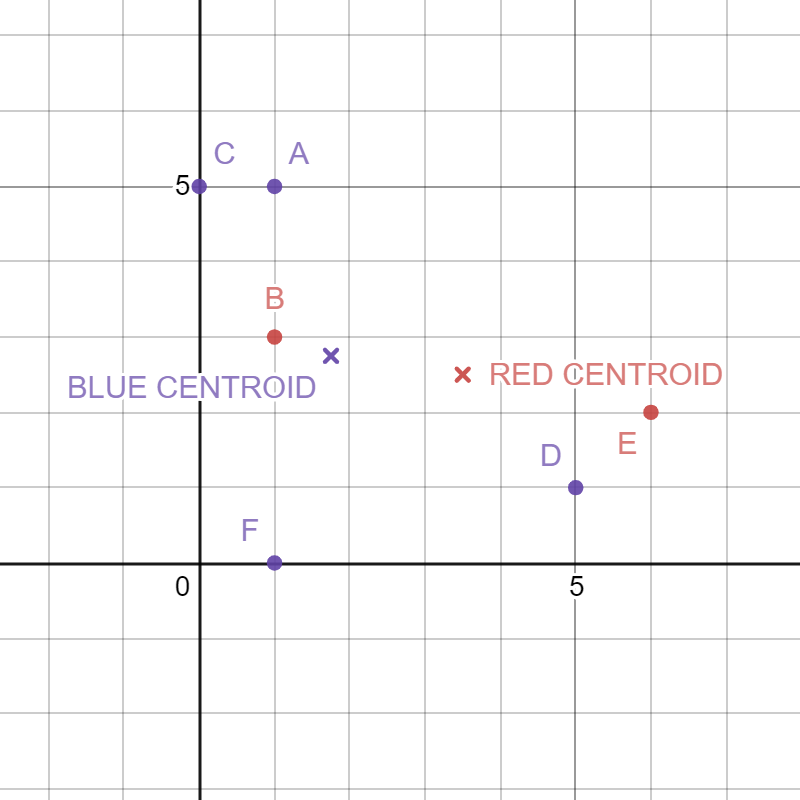

<img src="fig_note4_toy_data.png" alt="Figure 1" width="50%"/>

Coordinates of the blue centroid are
$$
\left(\frac{1+0+5+1}{4},\frac{5+5+1+0}{4}\right)=
(1.75, 2.75)
$$
Coordinates of the red centroid are
$$
\left(\frac{1+6}{2},\frac{3+2}{2}\right)
=(3.5, 2.5)
$$
Further, points $A$, $B$, and $C$ are, clearly, closer to
the blue centroid
than to the red one
and points $D$ and $E$ are closer to the red centroid
than to the blue one. Point $F$ is closer to the blue centroid,
but this is less obvious and may not be so evident if
we didn't have a nice picture from a graphing calculator.
Let us verify that point $F$ is closer to the blue centroid.
The square of the distance from $F$ to the blue centroid is
$$
\left(1.75-1\right)^{2}+2.75^{2}=8.125
$$
The square of the distance to the red centroid is
$$
\left(3.5-1\right)^{2}+2.5^{2}=12.5
$$
and we see that, indeed, point $F$ is closer to the blue
centroid.



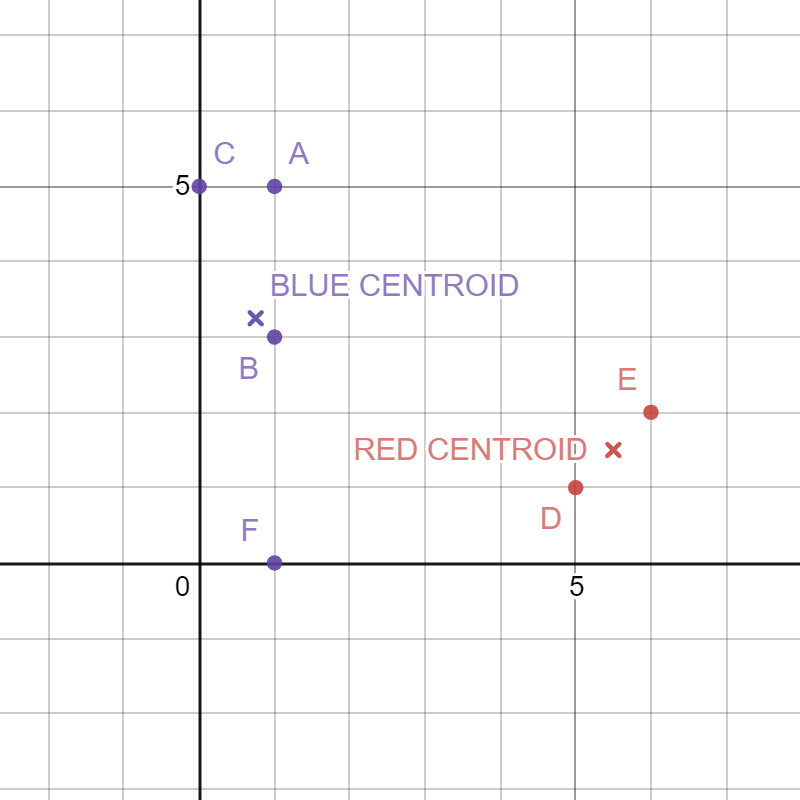


<img src="fig_note4_toy_data_answer.png" alt="Figure 2" width="50%"/>

The new blue centroid is
$$
\left(\frac{1+1+0+1}{4},\frac{5+3+5+0}{4}\right)=
(0.75, 3.25)
$$
and the new red centroid is
$$
\left(\frac{5+6}{2},\frac{1+2}{2}\right)=
(5.5,1.5)
$$
Finally, points that are closer to the blue centroid
than to the red centroid are precisely
points in the new blue cluster and points that are
closer to the red centroid than to the blue centroid
are precisely points in the new red cluster.
Thus the algorithm stabilized after the first iteration
and the answer is that $A,B,C,F$ form the blue cluster
and $D,E$ form the red cluster.

### Problem 2

Prove that $K$-means clustering algorithm stabilizes, i.e., after several iterations, new clusters are not going to change. Assume that distances from all training points to centroids of all subsets are different.

### Solution

For a hypothetical split
$$
T=C_1\sqcup C_2\sqcup\cdots\sqcup C_K
$$
of the training set into clusters,
let $\bar{x}_k$ be the centroid of cluster $C_k$.
Consider the following function:
$$
f(C_1,\dots,C_K)=\sum_{k=1}^{K}\sum_{i\in C_k}\|x^i-\bar{x}_k\|^2
$$
Note that after each iteration, the value of $f$ decreases because
every point is re-assigned to the cluster whose centroid is nearest. At the same time, the number of all possible
splits into clusters is finite and hence the process cannot
go on forever.

### Problem 3

So far we are familiar with the following machine learning algorithms:

* Linear regression

* Logistic regression

* Lasso ($l_1$-regularization)

* Principal Component Analysis

* $K$-means clustering

* Latent Dirichlet Allocation

There is a certain thing that we avoided discussing in class - data rescaling. Specifically, some of these algorithms don't work properly if our variables are measured on a different scale. For example, if we are predicting HDB prices using floor area in square feet (typical value is between 1000 and 2000), remaining lease in years (typical value is bettween 70 and 90), and town dummies (values are 0 or 1), then the fact that variables are measured on a different scale is going to seriously affect peformance of some of these models. To account for this fact, usually we pre-process the data by normalizing or standardizing them.

Normalizing the data is rescaling to the interval $[0, 1]$, i.e., applying the transformation
$$
X\leadsto \frac{X-\min(X)}{\max(X)-\min(X)}
$$
Standardizing is rescaling to get mean 0 and variance 1, i.e.,
$$
X\leadsto \frac{X-\bar{X}}{\mathrm{std}(X)}
$$
The choice of the rescaling algorithm is not very important, but it is important to know if such an algorithm is needed.

Very oftern, this is done under the hood by Python and R functions whenever necessary, but you should understand when this happens under the hood and when you need to do it explicitly.

For which of the algorithms listed above is data rescaling necessary and why?

### Solution

The model for linear regression is
$$
Y=\beta_0+\beta_1X_1+\cdots+\beta_pX_p
$$
The loss function is
$$
L(\beta)=\frac{1}{N}\sum_{i=1}^{N}\left(y^i-\beta_0-\beta_1x_1^i-\cdots-\beta_p x_p^i\right)^2
$$
Rescaling means multiplying and shifting a feature, i.e.,
$$
x_j\mapsto kx_j
$$
or
$$
x_j\mapsto x_j-c
$$
In both cases, both the model and the loss function can be rescaled accordingly. We can compensate for multiplying $x_j$ with $k$ by simply dividing $\beta_j$ by $k$. We can copensate for shifting $x_j$ by $c$ by simply shifting $\beta_0$ with $\beta_jc$. Thus, training a linear model does not require data rescaling. The same is true for logistic regression.

However, regularized models are different. Indeed, let's look at the LASSO linear regression with, say, $p=2$. The model is
$$
Y=\beta_0+\beta_1X_1+\beta_2X_2
$$
and the model doesn't change if we multiply $X_1$, say, by $10$ but divide $\beta_1$ by $10$. However, the loss function
$$
L(\beta_0,\beta_1,\beta_2)=\frac{1}{N}\sum_{i=1}^{N}\left(y^i-\beta_0-\beta_1x_1^i-\beta_2 x_2^i\right)^2+
\lambda(|\beta_1|+|\beta_2|)
$$
will change. Indeed, replacing $X_1$ with $10X_1$ and $\beta_1$ with $\beta_1/10$, we will get
$$
L(\beta_0,\beta_1/10,\beta_2)=\frac{1}{N}\sum_{i=1}^{N}\left(y^i-\beta_0-\beta_1x_1^i-\beta_2 x_2^i\right)^2+
\lambda(|\beta_1|/10+|\beta_2|),
$$
which is not the same thing. Effectively, variables with bigger absolute values will dominate the $l_1$ penalty term and hence the model will try to get rid of them to minimize the loss. In order to make the penalty term "fair" to all the variables, we need to rescale the data.

PCA works by replacing old (correlated) variables $\mathbf{X}$ with new (uncorrelated) variables $\mathbf{Z}$ by multiplying them with a suitable matrix $\varphi$, i.e.,
$$
\mathbf{Z}=\mathbf{X}\varphi
$$
Note that the matrix $\varphi$ is going to be orthonormal. Note that if we rescale $X_j$ by multiplying it with a constant $k$, it means that we multiply the corresponding column of $\mathbf{X}$ by $k$. To compensate for it, we can, of course, divide a row of $\varphi$ by $k$, yielding the same matrix $\mathbf{Z}$. However, the problem is that such a modified matrix $\varphi$ is not going to be orthonormal any more and hence rescaling the data changes the output of PCA.

Same concerns $K$-means clustering - rescaling the data changes the outcome. Indeed, let's think of the case $p=2$ and let's multiply $X_1$ by 10. In our toy example, the original points before rescaling are $A=(1,1)$, $B=(0,0)$ and $C=(0,2)$. Rescaling changes $A$ to $A'=(10,1)$ and doesn't change $B$ or $C$ as shown in this figure:

<img src="fig_note4_rescaling.png" alt="Figure 3" width="50%"/>

Note that before rescaling, the $A$ was closer to $C$ than $B$. But after rescaling $B$ is closer to $C$ than $A'$. If $A$ and $B$ were centroids of some clusters and $C$ were a data point, then the $K$-means clustering algorithm would work differently for the raw data and the rescaled data.

Essentially, $K$-means clustering is dominated by variables with large values, i.e., the situation here is somewhat opposite to regularized models (LASSO will try to get rid of variables with large values).

Finally, LDA is a topic modelling. It works with texts and it's just impossible to rescale text data. It doesn't really make sense to even think of rescaling for LDA.

Thus, data rescaling is crucial for regularization, for PCA, and for $K$-means clustering but not important for linear and logistic regression. Note that rescaling is often done automatically under the hood of machine learning routines in Python (and in R), so normally you won't have to manually go through your variables and normalize them. However, it's always advisable to check it because sometimes you need to explicitly specify that you want to do it.

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

